In [1]:
import pandas as pd

df = pd.read_csv("data.csv")

# Convert price to float
df["PRICE"] = df["PRICE"].astype(float)

# Convert rating text to numeric
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["RATING"] = df["RATING"].map(rating_map)

df.head()

,BOOKS'S TITLE,PRICE,RATING
0,A Light in the Attic,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History of Humankind,54.23,5


In [2]:
df.describe()

,PRICE,RATING
count,20.000000,20.000000
mean,38.048500,2.850000
std,15.135231,1.565248
min,13.990000,1.000000
25%,22.637500,1.000000
50%,41.380000,3.000000
75%,51.865000,4.000000
max,57.250000,5.000000


In [3]:
df.isnull().sum()

BOOKS'S TITLE    0
PRICE            0
RATING           0
dtype: int64

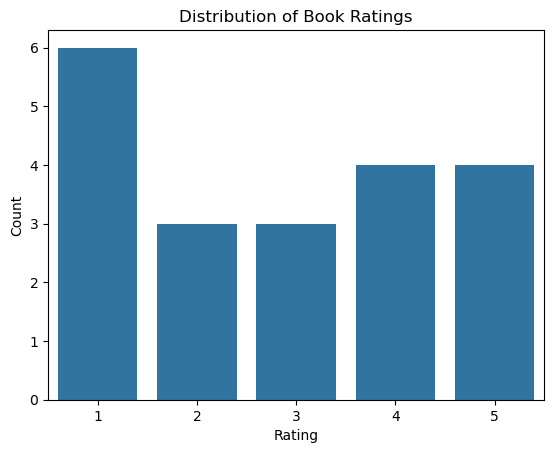

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="RATING", data=df)
plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

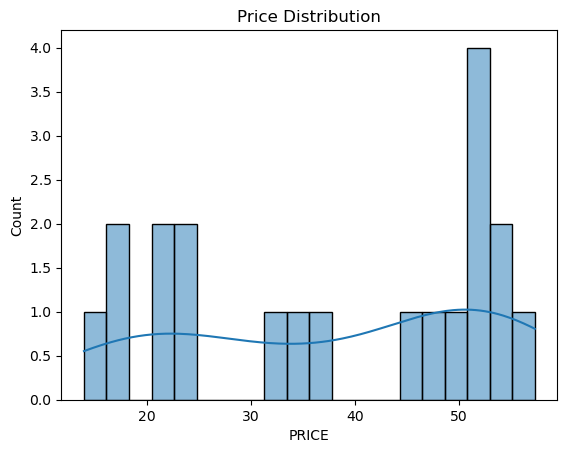

In [5]:
sns.histplot(df["PRICE"], bins=20, kde=True)
plt.title("Price Distribution")
plt.show()

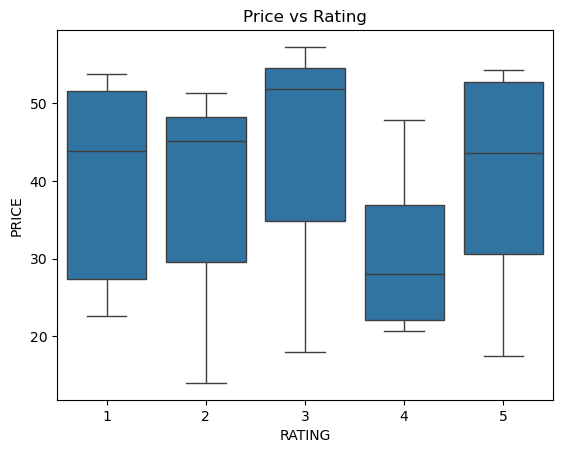

In [6]:
sns.boxplot(x="RATING", y="PRICE", data=df)
plt.title("Price vs Rating")
plt.show()

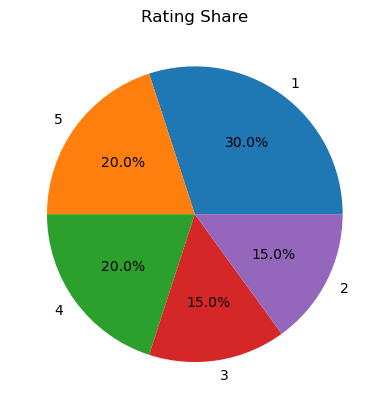

In [7]:
rating_counts = df["RATING"].value_counts()

plt.pie(rating_counts, labels=rating_counts.index, autopct="%1.1f%%")
plt.title("Rating Share")
plt.show()

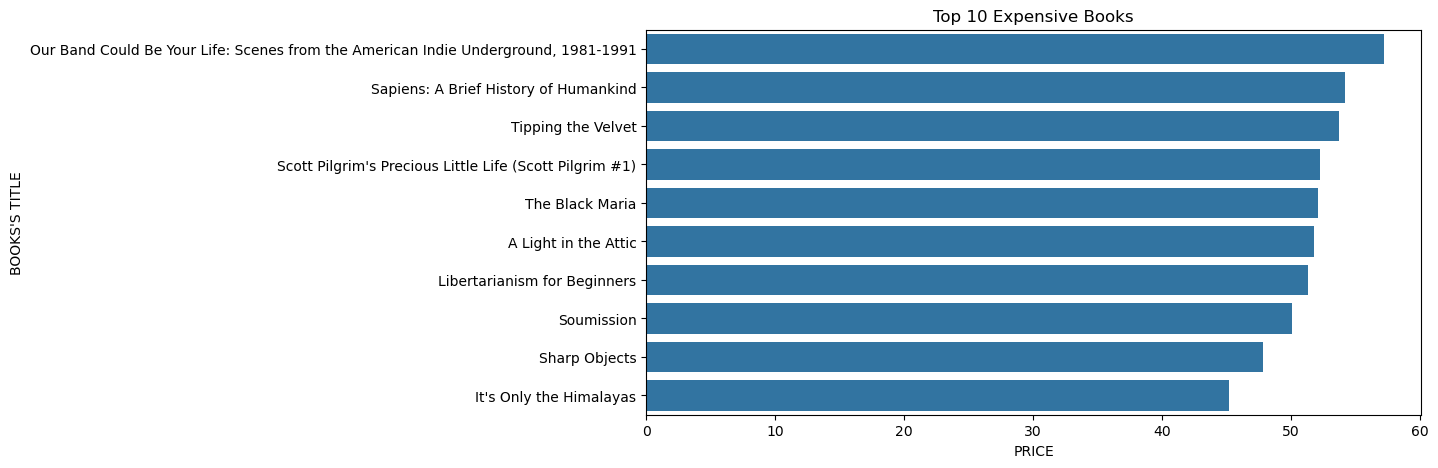

In [8]:
top_books = df.sort_values(by="PRICE", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x="PRICE", y="BOOKS'S TITLE", data=top_books)
plt.title("Top 10 Expensive Books")
plt.show()

In [9]:
df["TITLE_LENGTH"] = df["BOOKS'S TITLE"].apply(len)

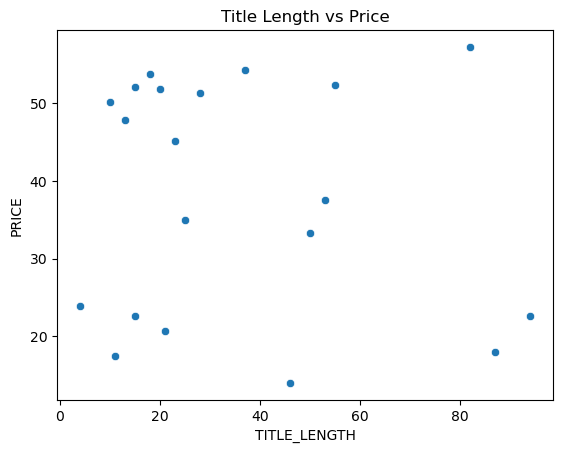

In [10]:
sns.scatterplot(x="TITLE_LENGTH", y="PRICE", data=df)
plt.title("Title Length vs Price")
plt.show()

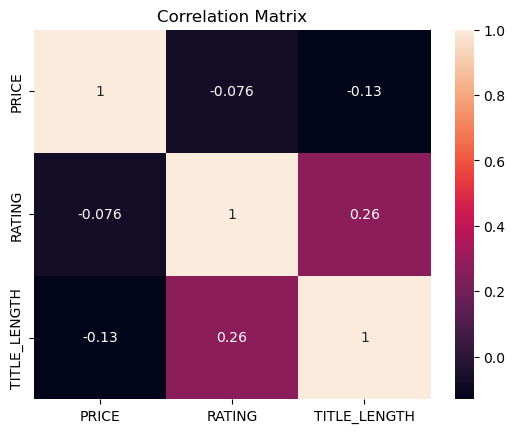

In [11]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["RATING", "TITLE_LENGTH"]]
y = df["PRICE"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: -1.0319130355932598
